In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# 1. Load the dataset
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

# 2. Basic Cleaning
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Convert date to datetime (handling timezones)
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)
df = df.dropna(subset=['headline', 'date']) # Remove rows with missing essential data

print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Loaded: 55987 rows, 5 columns


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A


--- Headline Length Statistics ---
count    55987.000000
mean        80.015254
std         56.126094
min         12.000000
25%         42.000000
50%         63.000000
75%         91.000000
max        512.000000
Name: headline_len, dtype: float64


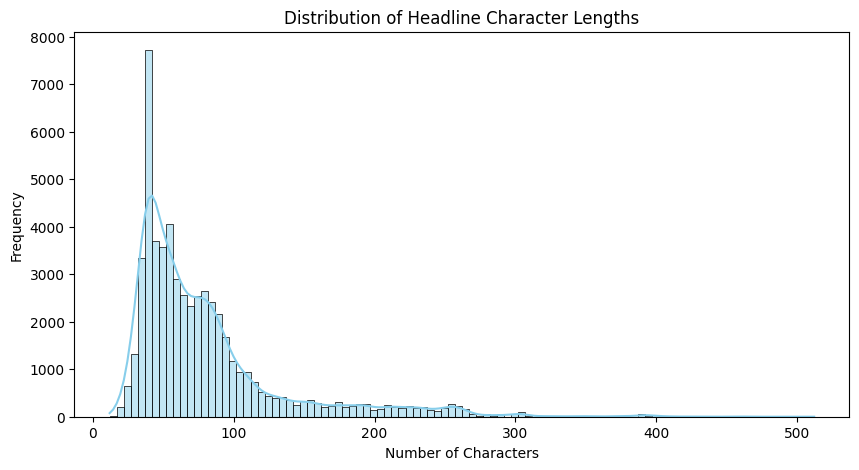

In [3]:
# Calculate headline character lengths
df['headline_len'] = df['headline'].apply(len)

print("--- Headline Length Statistics ---")
print(df['headline_len'].describe())

# Visualization
plt.figure(figsize=(10, 5))
sns.histplot(df['headline_len'], bins=100, kde=True, color='skyblue')
plt.title('Distribution of Headline Character Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

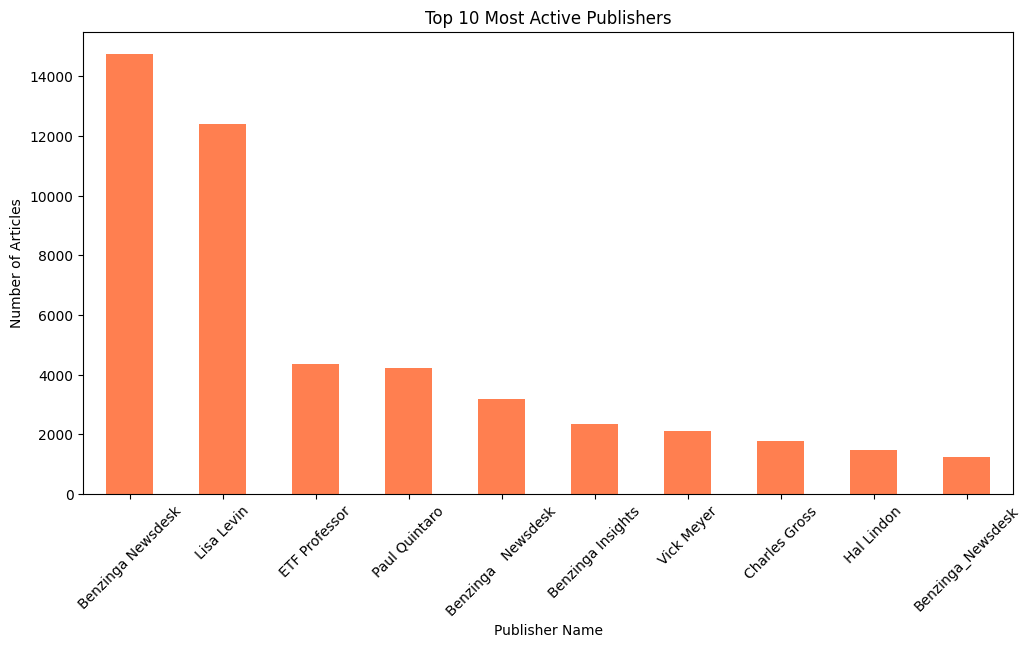

--- Top Publisher Domains ---
domains
benzinga.com    1196
gmail.com          3
Name: count, dtype: int64


In [4]:
# 1. Top 10 Publishers
top_publishers = df['publisher'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_publishers.plot(kind='bar', color='coral')
plt.title('Top 10 Most Active Publishers')
plt.xlabel('Publisher Name')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.show()

# 2. Extract Domains (if publishers are email addresses)
df['domains'] = df['publisher'].str.extract(r'@([\w\.-]+)')
domain_counts = df['domains'].value_counts()

if not domain_counts.empty:
    print("--- Top Publisher Domains ---")
    print(domain_counts.head(10))
else:
    print("No email-style publishers found.")

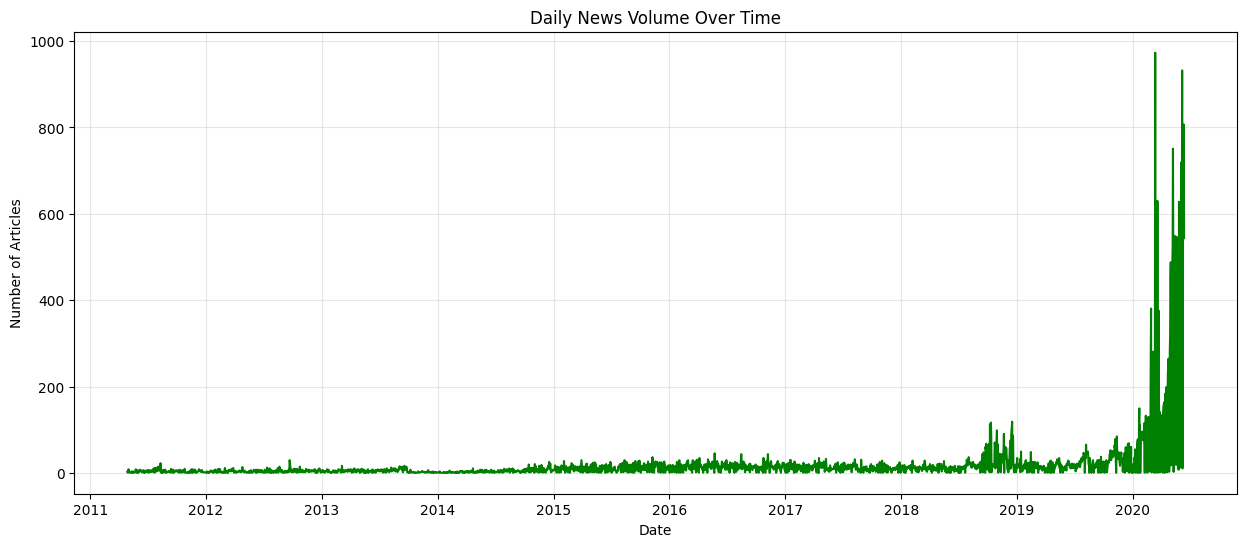

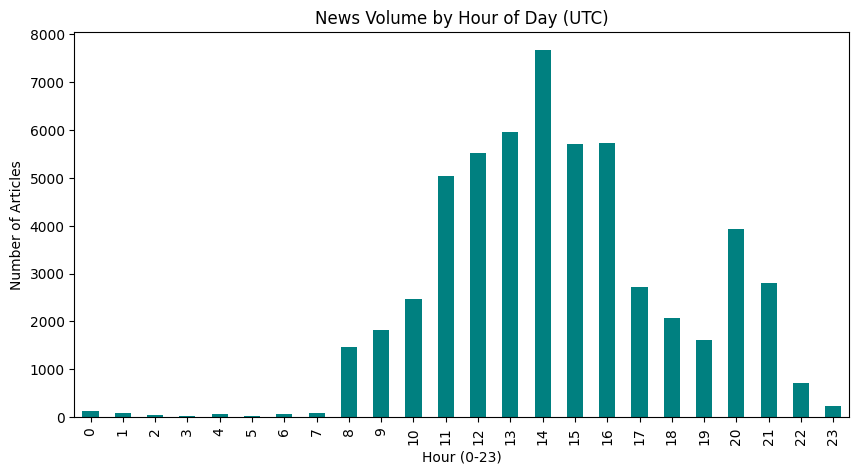

--- Dates with Significant News Spikes ---
publication_date
2020-05-29    309
2020-06-01    484
2020-06-02    361
2020-06-03    720
2020-06-04    538
2020-06-05    932
2020-06-08    765
2020-06-09    803
2020-06-10    807
2020-06-11    544
Name: count, dtype: int64


In [5]:
# 1. Daily News Volume
df['publication_date'] = df['date'].dt.date
daily_volume = df['publication_date'].value_counts().sort_index()

plt.figure(figsize=(15, 6))
daily_volume.plot(color='green')
plt.title('Daily News Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Hourly News Volume (Time of Day)
df['hour'] = df['date'].dt.hour
plt.figure(figsize=(10, 5))
df['hour'].value_counts().sort_index().plot(kind='bar', color='teal')
plt.title('News Volume by Hour of Day (UTC)')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Articles')
plt.show()

# 3. Identify Spikes
mean_vol = daily_volume.mean()
std_vol = daily_volume.std()
spikes = daily_volume[daily_volume > (mean_vol + 3 * std_vol)]
print("--- Dates with Significant News Spikes ---")
print(spikes.tail(10))

In [ ]:
# 1. WordCloud for common keywords
all_text = " ".join(headline for headline in df['headline'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Keywords in Headlines')
plt.show()

# 2. TF-IDF for Significant Phrases (Bigrams)
# This looks for pairs of words that appear together often
tfidf = TfidfVectorizer(stop_words='english', ngram_range=(2, 2), max_features=10)
tfidf_result = tfidf.fit_transform(df['headline'])
print("--- Top 10 Significant Phrases (TF-IDF) ---")
print(tfidf.get_feature_names_out())

# 3. CountVectorizer for top 10 themes
cv = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=10)
cv_result = cv.fit_transform(df['headline'])
print("\n--- Top 10 Recurring Themes (Count) ---")
print(cv.get_feature_names_out())